In [ ]:
import pandas as pd
import seaborn as sns

In [5]:
data_path = "../data/Customer-Churn-Records.csv"

df = pd.read_csv(data_path)
df.drop(columns=["RowNumber", "CustomerId", "Surname"], inplace=True)
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


<Axes: >

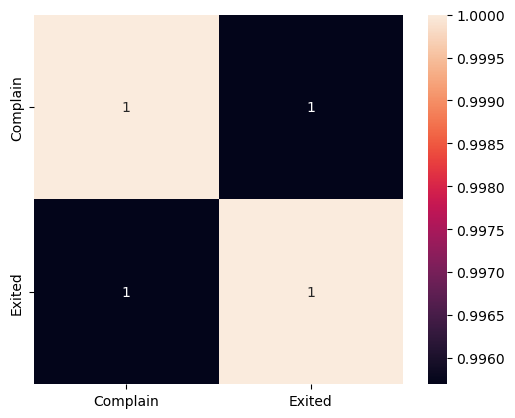

In [10]:
corr = df[["Complain", "Exited"]].corr()
sns.heatmap(corr, vmax=1, annot=True, square=True)

In [11]:
corr

,Complain,Exited
Complain,1.000000,0.995693
Exited,0.995693,1.000000


Given that the "Complain" feature is highly correlated to the target "Exited", it is best to remove it from the features as it might be a data leak

In [12]:
df.drop(columns=["Complain"], inplace=True)

Based on the `initial_report.html`, the observations are that:
- "CreditScore" is bimodal distributed with lots of outliers at 850.
- "Age" is right-skewed, with mean of 38.9 and median of 37, indicating that the dataset concentrates more on early to middle adulthood.
- "Balance" is also bimodal distributed with more than 36% at 0.
- "NumOfProducts" is mostly 1 and 2 with very few at 3 or 4.
- "EstimatedSalary" is uniform distributed as "Point Earned".
- Target "Exited" is not balanced with 79.62% not exited, a baseline at 80% accuracy
- No feature has null value

# Feature importance

## Churn rate and risk ratio

In [16]:
tot_churn = df.Exited.mean()

In [22]:
from IPython.display import display

cat = [
    "Geography",
    "Gender",
    "NumOfProducts",
    "HasCrCard",
    "IsActiveMember",
    "Satisfaction Score",
    "Card Type",
]

# Churn rate and risk ratio by each categorical feature
for c in cat:
    df_group = df.groupby(c).Exited.agg(["mean"])
    df_group["risk_ratio"] = df_group["mean"] / tot_churn
    display(df_group)

,mean,risk_ratio
Geography,,
France,0.161747,0.793656
Germany,0.324432,1.591914
Spain,0.166734,0.818125


,mean,risk_ratio
Gender,,
Female,0.250715,1.230203
Male,0.164743,0.808354


,mean,risk_ratio
NumOfProducts,,
1,0.277144,1.359882
2,0.076035,0.373086
3,0.827068,4.058232
4,1.000000,4.906771


,mean,risk_ratio
HasCrCard,,
0,0.208149,1.021342
1,0.201984,0.991091


,mean,risk_ratio
IsActiveMember,,
0,0.268715,1.318524
1,0.142691,0.700151


,mean,risk_ratio
Satisfaction Score,,
1,0.200311,0.982878
2,0.217974,1.069549
3,0.196376,0.963573
4,0.206175,1.011655
5,0.198104,0.972050


,mean,risk_ratio
Card Type,,
DIAMOND,0.217790,1.068647
GOLD,0.192646,0.945269
PLATINUM,0.203607,0.999054
SILVER,0.201122,0.986859


Based on the tables above, customers with more than 2 products are most certainly to churn.

## Mutual information

In [24]:
from sklearn.metrics import mutual_info_score


def mi_churn_score(series):
    return mutual_info_score(series, df.Exited)


mi = df[cat].apply(mi_churn_score)
mi.sort_values(ascending=False)

NumOfProducts         0.069840
Geography             0.013989
IsActiveMember        0.012328
Gender                0.005626
Card Type             0.000252
Satisfaction Score    0.000189
HasCrCard             0.000024
dtype: float64